# Run Validation for All Instruments

Ce notebook lance la validation complète de tous les instruments.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import os
from matplotlib.gridspec import GridSpec

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent.parent / 'notebooks'))

# Import Generic ETC
from Observation import Observation, load_instruments

# Import Astropy SNR function
try:
    from astropy.stats import signal_to_noise_oir_ccd
    ASTROPY_SNR_AVAILABLE = True
    print("✓ astropy.stats.signal_to_noise_oir_ccd available")
except ImportError:
    ASTROPY_SNR_AVAILABLE = False
    print("⚠ astropy.stats not available. Install with: pip install astropy")

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ astropy.stats.signal_to_noise_oir_ccd available
✓ Imports successful


In [2]:
# Load instrument database
instruments, database = load_instruments()

# Display available instruments
print(f"Available instruments ({len(instruments.colnames)-3}):")
for i, name in enumerate(instruments.colnames[3:], 1):
    print(f"  {i:2d}. {name}")

Available instruments (48):
   1. SCWI SPEC
   2. SCWI EMCCD
   3. SCWI Skipper
   4. SCWI CMOS
   5. SCWI MCP
   6. SCWI MIN REQ
   7. SCWI PERF
   8. ISTOS
DEEP
   9. FIREBall-2 2025
  10. FIREBall-2 2018
  11. FIREBall-1
  12. UVEX FUV
  13. UVEX NUV
  14. ASPERA
  15. JUNO UVS
  16. GALEX FUV
  17. GALEX NUV
  18. LUMOS
  19. CASTOR DMD
  20. CETUS
  21. KCWI blue
  22. KCWI red
  23. Blue MUSE
  24. NIRSPEC
  25. ELT Harmony
  26. MUSE wide
  27. MUSE narrow
  28. NISP
  29. SPHERE IRDIS
  30. SPHEREx
  31. tREXS
  32. POLLUX
  33. ARAGO
  34. CASSTOR
  35. LUMOS-MOS
  36. LUMOS-POINT
  37. LUMOS-IFS
  38. HST-COS
  39. HST-STIS
  40. SUMIRE PFS Blue
  41. VLT MOONS
  42. MOSAIC
  43. EUCLID vis
  44. MESSIER nuv
  45. UVEX fuv
  46. UVEX nuv
  47. GALEX fuv
  48. GALEX nuv


In [3]:
def calculate_SNR_astropy(signal_flux, sky_flux, collecting_area, throughput, QE, atmosphere,
                          pixel_scale, dispersion, wavelength_nm, exposure_time,
                          dark_current, read_noise, n_pixels=1):
    """
    Calculate SNR using astropy.stats.signal_to_noise_oir_ccd().
    
    Converts Generic ETC parameters to Astropy format.
    """
    # Convert flux (erg/cm²/s/arcsec²/Å) to photons/cm²/s/arcsec²/Å
    # E_photon = h * c / λ = 1.986e-8 [erg·Å] / λ[nm]
    E_photon = 1.986e-8 / wavelength_nm  # erg
    
    signal_photons_rate = signal_flux / E_photon  # photons/cm²/s/arcsec²/Å
    sky_photons_rate = sky_flux / E_photon        # photons/cm²/s/arcsec²/Å
    
    # Convert to electrons using telescope + instrument parameters
    collecting_area_cm2 = collecting_area * 1e4  # m² → cm²
    pixel_area_arcsec2 = pixel_scale**2          # arcsec²
    wavelength_range = dispersion                 # Å/pixel
    total_throughput = throughput * QE * atmosphere
    
    # source_eps: e⁻/s in aperture (summed over n_pixels)
    source_eps_per_pix = (signal_photons_rate * 
                          collecting_area_cm2 * 
                          pixel_area_arcsec2 * 
                          wavelength_range * 
                          total_throughput)
    source_eps = source_eps_per_pix * n_pixels  # Total in aperture
    
    # sky_eps: e⁻/s/pixel
    sky_eps = (sky_photons_rate * 
               collecting_area_cm2 * 
               pixel_area_arcsec2 * 
               wavelength_range * 
               total_throughput)
    
    # dark_eps: e⁻/s/pixel (convert from e⁻/pix/hour)
    dark_eps = dark_current / 3600.0
    
    # rd: read noise in e⁻ (already in correct units)
    rd = read_noise
    
    # Call Astropy function
    if not ASTROPY_SNR_AVAILABLE:
        return {'SNR': np.nan, 'error': 'Astropy not available'}
    
    snr = signal_to_noise_oir_ccd(
        t=exposure_time,
        source_eps=source_eps,
        sky_eps=sky_eps,
        dark_eps=dark_eps,
        rd=rd,
        npix=n_pixels,
        gain=1.0  # We work in electrons directly
    )
    
    return {
        'SNR': snr,
        'source_eps': source_eps,
        'sky_eps': sky_eps,
        'dark_eps': dark_eps,
        'rd': rd,
        'npix': n_pixels
    }

print("✓ Astropy SNR wrapper function defined")

✓ Astropy SNR wrapper function defined


In [7]:
def validate_instrument(instrument_name, instruments, output_dir='./images/'):
    """
    Validate Generic ETC against Astropy SNR for a given instrument.
    
    Tests multiple parameters:
    1. Exposure time
    2. Signal flux
    3. Sky background
    4. Read noise
    5. Dark current
    """
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Extract instrument parameters
    try:
        idx = list(instruments.colnames).index(instrument_name)
    except ValueError:
        print(f"⚠ Instrument '{instrument_name}' not found")
        return None
    
    params = {}
    for i, charact in enumerate(instruments['Charact.']):
        if charact and not isinstance(charact, np.ma.core.MaskedConstant):
            value = instruments[instrument_name][i]
            if not isinstance(value, np.ma.core.MaskedConstant):
                params[charact] = value
    
    # Check for required parameters
    required_params = ['Signal', 'Sky', 'Collecting_area', 'Throughput', 'QE',
                      'Atmosphere', 'pixel_scale', 'dispersion', 'wavelength',
                      'Dark_current', 'RN']
    missing_params = [p for p in required_params if p not in params]
    if missing_params:
        print(f"⚠ {instrument_name}: Missing parameters {missing_params}")
        return None
    
    # Check if EMCCD (skip if EM_gain > 1, Astropy doesn't support it)
    em_gain = params.get('EM_gain', 1.0)
    if em_gain > 1.0:
        print(f"⚠ {instrument_name}: EMCCD detected (EM_gain={em_gain}), skipping")
        return None
    
    print(f"\n{'='*60}")
    print(f"Validating: {instrument_name}")
    print(f"{'='*60}")
    
    # Common parameters
    signal_flux_nominal = params['Signal']
    sky_flux_nominal = params['Sky']
    collecting_area = params['Collecting_area']
    throughput = params['Throughput']
    QE = params['QE']
    atmosphere = params['Atmosphere']
    pixel_scale = params['pixel_scale']
    dispersion = params['dispersion']
    wavelength_nm = params['wavelength']
    dark_current_nominal = params['Dark_current']
    read_noise_nominal = params['RN']
    exposure_time_nominal = params.get('exposure_time', 1000.0)
    
    # Create figure with 5 subplots (3 rows, 4 cols)
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(3, 4, figure=fig, hspace=0.3, wspace=0.3)
    
    results = {}
    
    # Test 1: Exposure Time
    print("  Testing exposure time variation...")
    exposure_times = np.logspace(1, 4, 15)
    snr_generic_exp = []
    snr_astropy_exp = []
    
    for t_exp in exposure_times:
        obs = Observation(
            instruments=instruments,
            instrument=instrument_name,
            exposure_time=t_exp,
            acquisition_time=t_exp,
            SNR_res="per pix",
            IFS=False,
            test=False
        )
        snr_generic_exp.append(obs.SNR[obs.i])
        
        result = calculate_SNR_astropy(
            signal_flux=signal_flux_nominal,
            sky_flux=sky_flux_nominal,
            collecting_area=collecting_area,
            throughput=throughput,
            QE=QE,
            atmosphere=atmosphere,
            pixel_scale=pixel_scale,
            dispersion=dispersion,
            wavelength_nm=wavelength_nm,
            exposure_time=t_exp,
            dark_current=dark_current_nominal,
            read_noise=read_noise_nominal,
            n_pixels=1
        )
        snr_astropy_exp.append(result['SNR'])
    
    snr_generic_exp = np.array(snr_generic_exp)
    snr_astropy_exp = np.array(snr_astropy_exp)
    relative_diff_exp = 100 * (snr_generic_exp - snr_astropy_exp) / snr_astropy_exp
    
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.loglog(exposure_times, snr_generic_exp, 'o-', label='Generic ETC', linewidth=2, markersize=4)
    ax1.loglog(exposure_times, snr_astropy_exp, 's--', label='Astropy', linewidth=2, alpha=0.7, markersize=4)
    ax1.set_xlabel('Exposure Time (s)', fontsize=10)
    ax1.set_ylabel('SNR', fontsize=10)
    ax1.set_title('SNR vs Exposure Time', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.semilogx(exposure_times, relative_diff_exp, 'o-', color='red', linewidth=2, markersize=4)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    ax2.axhline(15, color='orange', linestyle=':', linewidth=1)
    ax2.axhline(-15, color='orange', linestyle=':', linewidth=1)
    ax2.set_xlabel('Exposure Time (s)', fontsize=10)
    ax2.set_ylabel('Relative Diff (%)', fontsize=10)
    ax2.set_title(f'Max: {np.max(np.abs(relative_diff_exp)):.1f}%', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    results['exposure_time'] = {
        'mean_diff': np.mean(relative_diff_exp),
        'max_diff': np.max(np.abs(relative_diff_exp)),
        'std_diff': np.std(relative_diff_exp)
    }
    
    # Test 2: Signal Flux
    print("  Testing signal flux variation...")
    signal_factors = np.logspace(-1, 1, 15)
    snr_generic_sig = []
    snr_astropy_sig = []
    
    for factor in signal_factors:
        signal_flux = signal_flux_nominal * factor
        original_signal = instruments[instrument_name][list(instruments['Charact.']).index('Signal')]
        instruments[instrument_name][list(instruments['Charact.']).index('Signal')] = signal_flux
        
        obs = Observation(
            instruments=instruments,
            instrument=instrument_name,
            exposure_time=exposure_time_nominal,
            acquisition_time=exposure_time_nominal,
            SNR_res="per pix",
            IFS=False,
            test=False
        )
        snr_generic_sig.append(obs.SNR[obs.i])
        instruments[instrument_name][list(instruments['Charact.']).index('Signal')] = original_signal
        
        result = calculate_SNR_astropy(
            signal_flux=signal_flux,
            sky_flux=sky_flux_nominal,
            collecting_area=collecting_area,
            throughput=throughput,
            QE=QE,
            atmosphere=atmosphere,
            pixel_scale=pixel_scale,
            dispersion=dispersion,
            wavelength_nm=wavelength_nm,
            exposure_time=exposure_time_nominal,
            dark_current=dark_current_nominal,
            read_noise=read_noise_nominal,
            n_pixels=1
        )
        snr_astropy_sig.append(result['SNR'])
    
    snr_generic_sig = np.array(snr_generic_sig)
    snr_astropy_sig = np.array(snr_astropy_sig)
    relative_diff_sig = 100 * (snr_generic_sig - snr_astropy_sig) / snr_astropy_sig
    
    ax3 = fig.add_subplot(gs[0, 1])
    ax3.loglog(signal_factors, snr_generic_sig, 'o-', label='Generic ETC', linewidth=2, markersize=4)
    ax3.loglog(signal_factors, snr_astropy_sig, 's--', label='Astropy', linewidth=2, alpha=0.7, markersize=4)
    ax3.set_xlabel('Signal Factor (×nominal)', fontsize=10)
    ax3.set_ylabel('SNR', fontsize=10)
    ax3.set_title('SNR vs Signal Flux', fontsize=11, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.semilogx(signal_factors, relative_diff_sig, 'o-', color='red', linewidth=2, markersize=4)
    ax4.axhline(0, color='black', linestyle='--', linewidth=1)
    ax4.axhline(15, color='orange', linestyle=':', linewidth=1)
    ax4.axhline(-15, color='orange', linestyle=':', linewidth=1)
    ax4.set_xlabel('Signal Factor', fontsize=10)
    ax4.set_ylabel('Relative Diff (%)', fontsize=10)
    ax4.set_title(f'Max: {np.max(np.abs(relative_diff_sig)):.1f}%', fontsize=10)
    ax4.grid(True, alpha=0.3)
    
    results['signal_flux'] = {
        'mean_diff': np.mean(relative_diff_sig),
        'max_diff': np.max(np.abs(relative_diff_sig)),
        'std_diff': np.std(relative_diff_sig)
    }
    
    # Test 3: Sky Background (similar structure)
    print("  Testing sky background variation...")
    sky_factors = np.logspace(-1, 1, 15)
    snr_generic_sky = []
    snr_astropy_sky = []
    
    for factor in sky_factors:
        sky_flux = sky_flux_nominal * factor
        original_sky = instruments[instrument_name][list(instruments['Charact.']).index('Sky')]
        instruments[instrument_name][list(instruments['Charact.']).index('Sky')] = sky_flux
        
        obs = Observation(
            instruments=instruments,
            instrument=instrument_name,
            exposure_time=exposure_time_nominal,
            acquisition_time=exposure_time_nominal,
            SNR_res="per pix",
            IFS=False,
            test=False,
        )
        snr_generic_sky.append(obs.SNR[obs.i])
        instruments[instrument_name][list(instruments['Charact.']).index('Sky')] = original_sky
        
        result = calculate_SNR_astropy(
            signal_flux=signal_flux_nominal,
            sky_flux=sky_flux,
            collecting_area=collecting_area,
            throughput=throughput,
            QE=QE,
            atmosphere=atmosphere,
            pixel_scale=pixel_scale,
            dispersion=dispersion,
            wavelength_nm=wavelength_nm,
            exposure_time=exposure_time_nominal,
            dark_current=dark_current_nominal,
            read_noise=read_noise_nominal,
            n_pixels=1
        )
        snr_astropy_sky.append(result['SNR'])
    
    snr_generic_sky = np.array(snr_generic_sky)
    snr_astropy_sky = np.array(snr_astropy_sky)
    relative_diff_sky = 100 * (snr_generic_sky - snr_astropy_sky) / snr_astropy_sky
    
    ax5 = fig.add_subplot(gs[0, 2])
    ax5.loglog(sky_factors, snr_generic_sky, 'o-', label='Generic ETC', linewidth=2, markersize=4)
    ax5.loglog(sky_factors, snr_astropy_sky, 's--', label='Astropy', linewidth=2, alpha=0.7, markersize=4)
    ax5.set_xlabel('Sky Factor (×nominal)', fontsize=10)
    ax5.set_ylabel('SNR', fontsize=10)
    ax5.set_title('SNR vs Sky Background', fontsize=11, fontweight='bold')
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)
    
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.semilogx(sky_factors, relative_diff_sky, 'o-', color='red', linewidth=2, markersize=4)
    ax6.axhline(0, color='black', linestyle='--', linewidth=1)
    ax6.axhline(15, color='orange', linestyle=':', linewidth=1)
    ax6.axhline(-15, color='orange', linestyle=':', linewidth=1)
    ax6.set_xlabel('Sky Factor', fontsize=10)
    ax6.set_ylabel('Relative Diff (%)', fontsize=10)
    ax6.set_title(f'Max: {np.max(np.abs(relative_diff_sky)):.1f}%', fontsize=10)
    ax6.grid(True, alpha=0.3)
    
    results['sky_background'] = {
        'mean_diff': np.mean(relative_diff_sky),
        'max_diff': np.max(np.abs(relative_diff_sky)),
        'std_diff': np.std(relative_diff_sky)
    }
    
    # Test 4: Read Noise
    print("  Testing read noise variation...")
    if read_noise_nominal > 0.1:
        read_noise_values = np.linspace(0.1, read_noise_nominal * 5, 15)
        snr_generic_rn = []
        snr_astropy_rn = []
        
        for rn in read_noise_values:
            original_rn = instruments[instrument_name][list(instruments['Charact.']).index('RN')]
            instruments[instrument_name][list(instruments['Charact.']).index('RN')] = rn
            
            obs = Observation(
                instruments=instruments,
                instrument=instrument_name,
                exposure_time=exposure_time_nominal,
                acquisition_time=exposure_time_nominal,
                SNR_res="per pix",
                IFS=False,
                test=False,
            )
            snr_generic_rn.append(obs.SNR[obs.i])
            instruments[instrument_name][list(instruments['Charact.']).index('RN')] = original_rn
            
            result = calculate_SNR_astropy(
                signal_flux=signal_flux_nominal,
                sky_flux=sky_flux_nominal,
                collecting_area=collecting_area,
                throughput=throughput,
                QE=QE,
                atmosphere=atmosphere,
                pixel_scale=pixel_scale,
                dispersion=dispersion,
                wavelength_nm=wavelength_nm,
                exposure_time=exposure_time_nominal,
                dark_current=dark_current_nominal,
                read_noise=rn,
                n_pixels=1
            )
            snr_astropy_rn.append(result['SNR'])
        
        snr_generic_rn = np.array(snr_generic_rn)
        snr_astropy_rn = np.array(snr_astropy_rn)
        relative_diff_rn = 100 * (snr_generic_rn - snr_astropy_rn) / snr_astropy_rn
        
        ax7 = fig.add_subplot(gs[0, 3])
        ax7.plot(read_noise_values, snr_generic_rn, 'o-', label='Generic ETC', linewidth=2, markersize=4)
        ax7.plot(read_noise_values, snr_astropy_rn, 's--', label='Astropy', linewidth=2, alpha=0.7, markersize=4)
        ax7.set_xlabel('Read Noise (e⁻)', fontsize=10)
        ax7.set_ylabel('SNR', fontsize=10)
        ax7.set_title('SNR vs Read Noise', fontsize=11, fontweight='bold')
        ax7.legend(fontsize=9)
        ax7.grid(True, alpha=0.3)
        
        ax8 = fig.add_subplot(gs[1, 3])
        ax8.plot(read_noise_values, relative_diff_rn, 'o-', color='red', linewidth=2, markersize=4)
        ax8.axhline(0, color='black', linestyle='--', linewidth=1)
        ax8.axhline(15, color='orange', linestyle=':', linewidth=1)
        ax8.axhline(-15, color='orange', linestyle=':', linewidth=1)
        ax8.set_xlabel('Read Noise (e⁻)', fontsize=10)
        ax8.set_ylabel('Relative Diff (%)', fontsize=10)
        ax8.set_title(f'Max: {np.max(np.abs(relative_diff_rn)):.1f}%', fontsize=10)
        ax8.grid(True, alpha=0.3)
        
        results['read_noise'] = {
            'mean_diff': np.mean(relative_diff_rn),
            'max_diff': np.max(np.abs(relative_diff_rn)),
            'std_diff': np.std(relative_diff_rn)
        }
    else:
        ax7 = fig.add_subplot(gs[0, 3])
        ax7.text(0.5, 0.5, 'Read Noise ≈ 0\n(Not tested)',
                ha='center', va='center', fontsize=12, transform=ax7.transAxes)
        ax7.axis('off')
        ax8 = fig.add_subplot(gs[1, 3])
        ax8.axis('off')
        results['read_noise'] = None
    
    # Test 5: Dark Current
    print("  Testing dark current variation...")
    if dark_current_nominal > 0.01:
        dark_current_values = np.linspace(0.01, dark_current_nominal * 5, 15)
        snr_generic_dc = []
        snr_astropy_dc = []
        
        for dc in dark_current_values:
            original_dc = instruments[instrument_name][list(instruments['Charact.']).index('Dark_current')]
            instruments[instrument_name][list(instruments['Charact.']).index('Dark_current')] = dc
            
            obs = Observation(
                instruments=instruments,
                instrument=instrument_name,
                exposure_time=exposure_time_nominal,
                acquisition_time=exposure_time_nominal,
                SNR_res="per pix",
                IFS=False,
                test=False,
            )
            snr_generic_dc.append(obs.SNR[obs.i])
            instruments[instrument_name][list(instruments['Charact.']).index('Dark_current')] = original_dc
            
            result = calculate_SNR_astropy(
                signal_flux=signal_flux_nominal,
                sky_flux=sky_flux_nominal,
                collecting_area=collecting_area,
                throughput=throughput,
                QE=QE,
                atmosphere=atmosphere,
                pixel_scale=pixel_scale,
                dispersion=dispersion,
                wavelength_nm=wavelength_nm,
                exposure_time=exposure_time_nominal,
                dark_current=dc,
                read_noise=read_noise_nominal,
                n_pixels=1
            )
            snr_astropy_dc.append(result['SNR'])
        
        snr_generic_dc = np.array(snr_generic_dc)
        snr_astropy_dc = np.array(snr_astropy_dc)
        relative_diff_dc = 100 * (snr_generic_dc - snr_astropy_dc) / snr_astropy_dc
        
        ax9 = fig.add_subplot(gs[2, 0:2])
        ax9.plot(dark_current_values, snr_generic_dc, 'o-', label='Generic ETC', linewidth=2, markersize=4)
        ax9.plot(dark_current_values, snr_astropy_dc, 's--', label='Astropy', linewidth=2, alpha=0.7, markersize=4)
        ax9.set_xlabel('Dark Current (e⁻/pix/hour)', fontsize=10)
        ax9.set_ylabel('SNR', fontsize=10)
        ax9.set_title('SNR vs Dark Current', fontsize=11, fontweight='bold')
        ax9.legend(fontsize=9)
        ax9.grid(True, alpha=0.3)
        
        ax10 = fig.add_subplot(gs[2, 2:4])
        ax10.plot(dark_current_values, relative_diff_dc, 'o-', color='red', linewidth=2, markersize=4)
        ax10.axhline(0, color='black', linestyle='--', linewidth=1)
        ax10.axhline(15, color='orange', linestyle=':', linewidth=1)
        ax10.axhline(-15, color='orange', linestyle=':', linewidth=1)
        ax10.set_xlabel('Dark Current (e⁻/pix/hour)', fontsize=10)
        ax10.set_ylabel('Relative Diff (%)', fontsize=10)
        ax10.set_title(f'Max: {np.max(np.abs(relative_diff_dc)):.1f}%', fontsize=10)
        ax10.grid(True, alpha=0.3)
        
        results['dark_current'] = {
            'mean_diff': np.mean(relative_diff_dc),
            'max_diff': np.max(np.abs(relative_diff_dc)),
            'std_diff': np.std(relative_diff_dc)
        }
    else:
        ax9 = fig.add_subplot(gs[2, 0:2])
        ax9.text(0.5, 0.5, 'Dark Current ≈ 0\n(Not tested)',
                ha='center', va='center', fontsize=12, transform=ax9.transAxes)
        ax9.axis('off')
        ax10 = fig.add_subplot(gs[2, 2:4])
        ax10.axis('off')
        results['dark_current'] = None
    
    # Main title
    fig.suptitle(f'{instrument_name} - Validation vs Astropy SNR',
                fontsize=16, fontweight='bold', y=0.995)
    
    # Save figure
    output_path = os.path.join(output_dir, f'{instrument_name.replace(" ", "_")}.png')
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {output_path}")
    plt.show()
    
    # Print summary
    print(f"\n  Results Summary:")
    for test_name, test_results in results.items():
        if test_results is not None:
            status = "✓✓" if test_results['max_diff'] < 10 else "✓" if test_results['max_diff'] < 15 else "✗"
            print(f"    {test_name:20s}: {status} Max diff = {test_results['max_diff']:6.2f}%")
        else:
            print(f"    {test_name:20s}: -- (not tested)")
    
    overall_max = max([r['max_diff'] for r in results.values() if r is not None])
    print(f"  Overall max difference: {overall_max:.2f}%")
    if overall_max < 10:
        print(f"  Overall result: ✓✓ EXCELLENT")
    elif overall_max < 15:
        print(f"  Overall result: ✓ PASSED")
    else:
        print(f"  Overall result: ✗ FAILED")
    print(f"{'='*60}\n")
    
    results['overall_max_diff'] = overall_max
    results['instrument_name'] = instrument_name
    
    return results

print("✓ Validation function defined")

✓ Validation function defined


---

## Test sur quelques instruments clés

Commençons par tester quelques instruments représentatifs.

Testing 4 key instruments...


Validating: GALEX FUV
  Testing exposure time variation...
  Testing signal flux variation...
  Testing sky background variation...
  Testing read noise variation...
  Testing dark current variation...
  ✓ Saved: /Users/Vincent/Github/generic-etc/test/cross-validation/images/GALEX_FUV.png


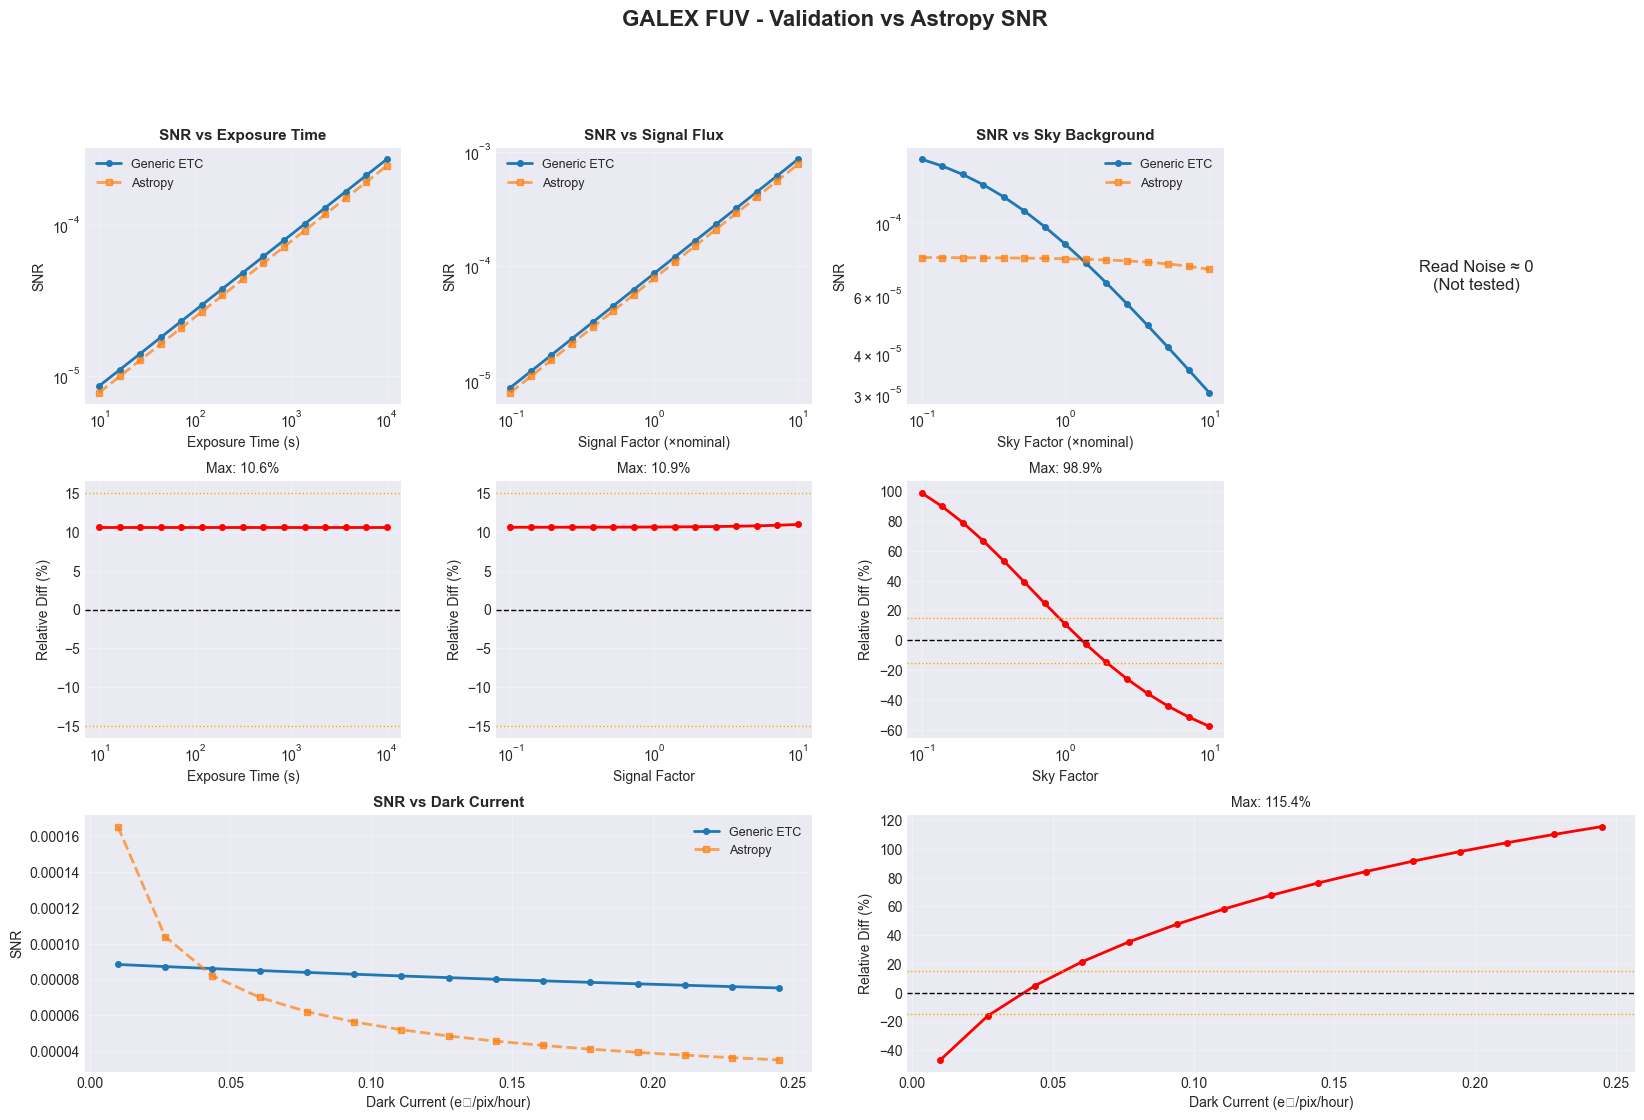


  Results Summary:
    exposure_time       : ✓ Max diff =  10.62%
    signal_flux         : ✓ Max diff =  10.94%
    sky_background      : ✗ Max diff =  98.88%
    read_noise          : -- (not tested)
    dark_current        : ✗ Max diff = 115.42%
  Overall max difference: 115.42%
  Overall result: ✗ FAILED


Validating: GALEX NUV
  Testing exposure time variation...
  Testing signal flux variation...
  Testing sky background variation...
  Testing read noise variation...
  Testing dark current variation...
  ✓ Saved: /Users/Vincent/Github/generic-etc/test/cross-validation/images/GALEX_NUV.png


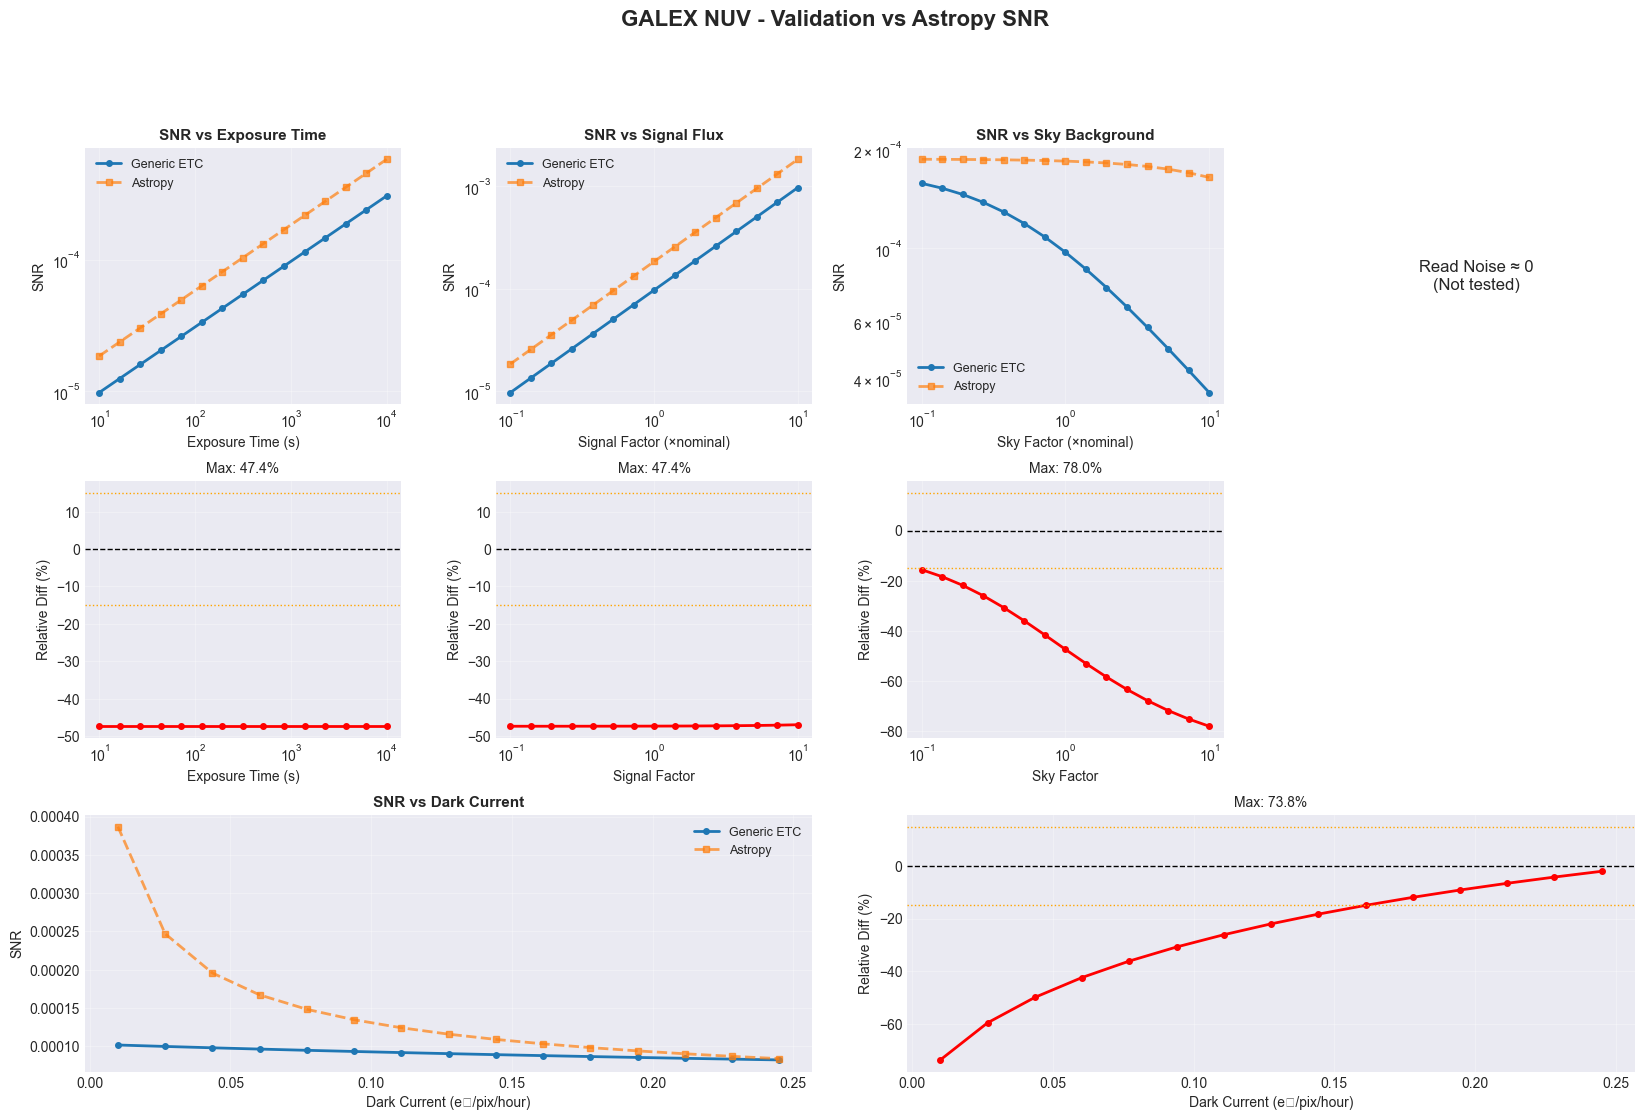


  Results Summary:
    exposure_time       : ✗ Max diff =  47.37%
    signal_flux         : ✗ Max diff =  47.40%
    sky_background      : ✗ Max diff =  78.01%
    read_noise          : -- (not tested)
    dark_current        : ✗ Max diff =  73.77%
  Overall max difference: 78.01%
  Overall result: ✗ FAILED


Validating: UVEX FUV
  Testing exposure time variation...
  Testing signal flux variation...
  Testing sky background variation...
  Testing read noise variation...
  Testing dark current variation...
  ✓ Saved: /Users/Vincent/Github/generic-etc/test/cross-validation/images/UVEX_FUV.png


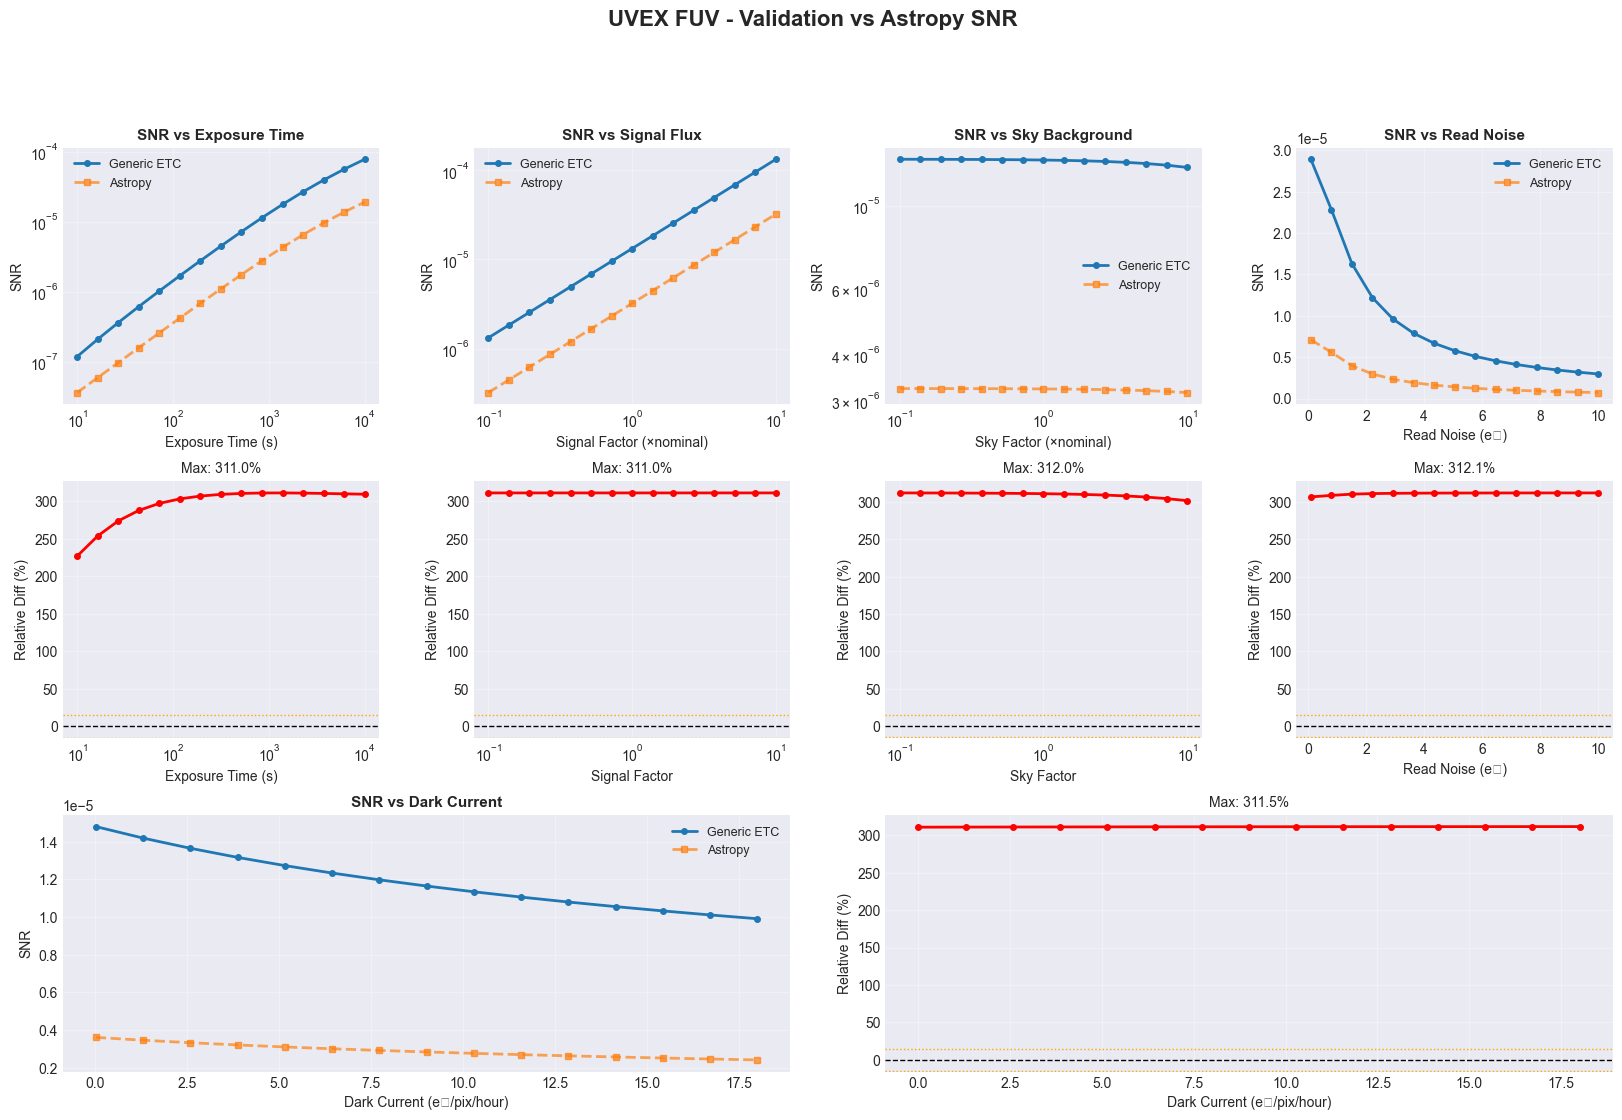


  Results Summary:
    exposure_time       : ✗ Max diff = 311.04%
    signal_flux         : ✗ Max diff = 311.02%
    sky_background      : ✗ Max diff = 312.04%
    read_noise          : ✗ Max diff = 312.09%
    dark_current        : ✗ Max diff = 311.52%
  Overall max difference: 312.09%
  Overall result: ✗ FAILED


Validating: UVEX NUV
  Testing exposure time variation...
  Testing signal flux variation...
  Testing sky background variation...
  Testing read noise variation...
  Testing dark current variation...
  ✓ Saved: /Users/Vincent/Github/generic-etc/test/cross-validation/images/UVEX_NUV.png


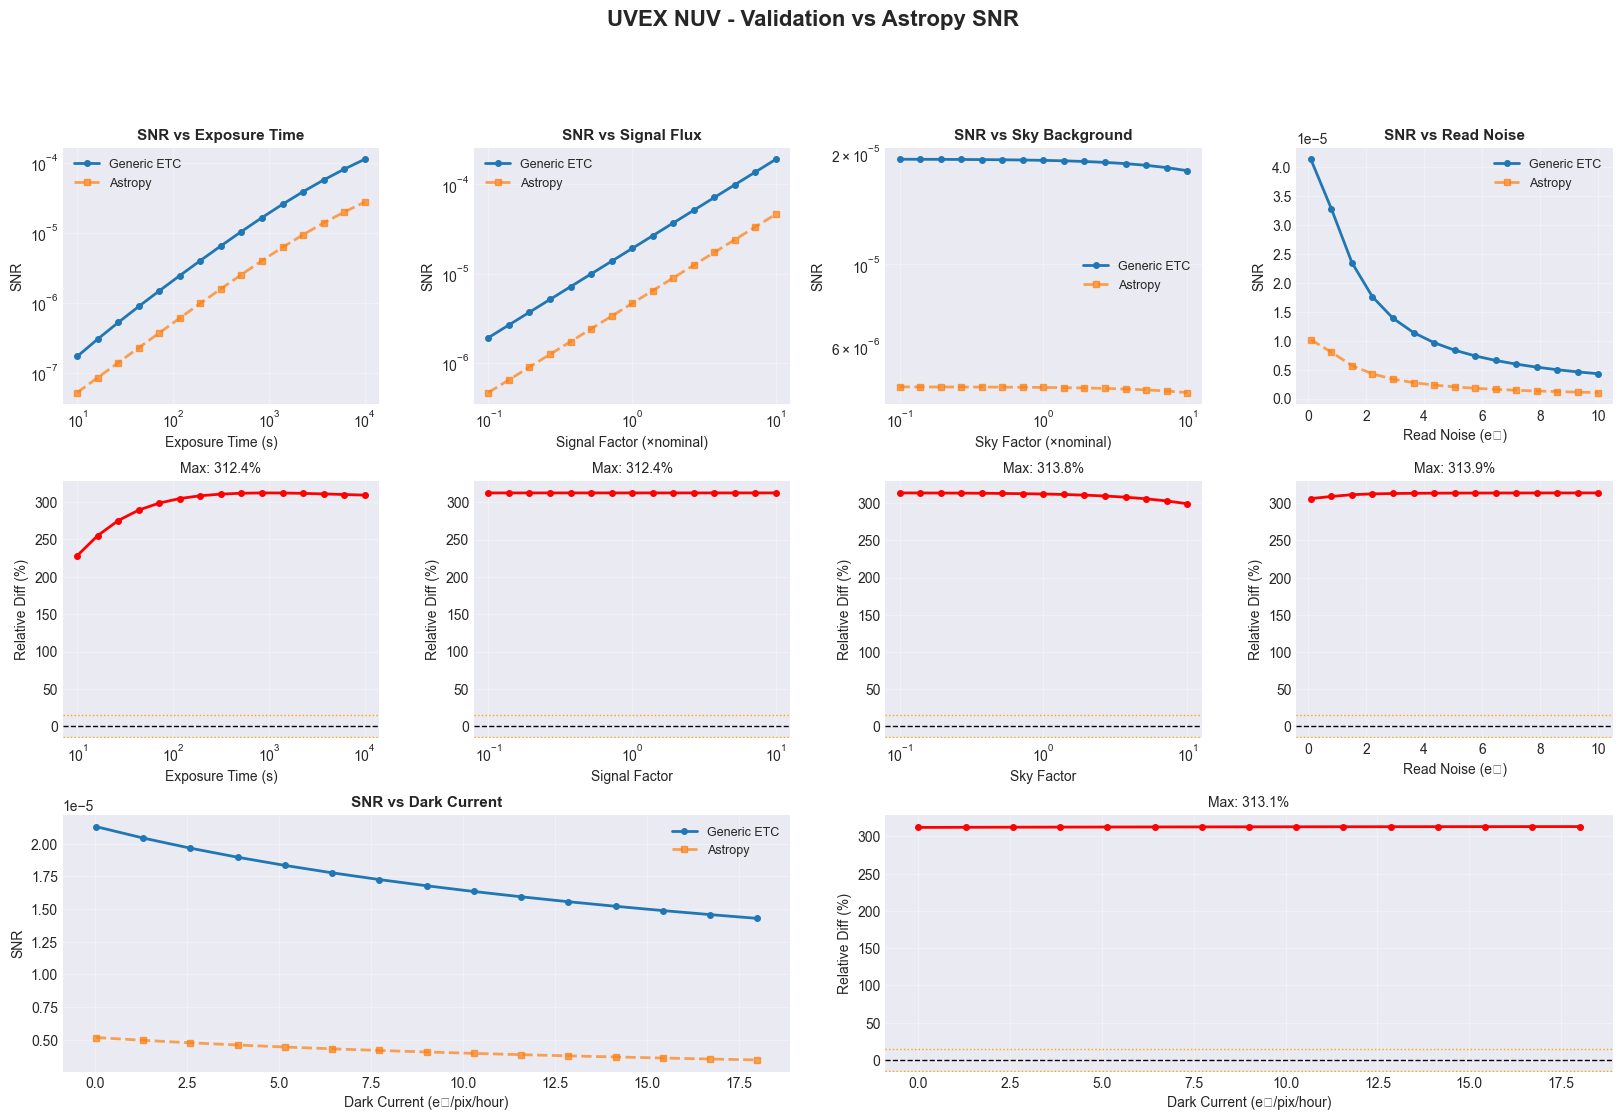


  Results Summary:
    exposure_time       : ✗ Max diff = 312.35%
    signal_flux         : ✗ Max diff = 312.37%
    sky_background      : ✗ Max diff = 313.85%
    read_noise          : ✗ Max diff = 313.93%
    dark_current        : ✗ Max diff = 313.09%
  Overall max difference: 313.93%
  Overall result: ✗ FAILED


SUMMARY FOR KEY INSTRUMENTS
Instrument                Overall Max Diff     Status
--------------------------------------------------------------------------------
GALEX FUV                 115.42%             ✗ FAILED
GALEX NUV                  78.01%             ✗ FAILED
UVEX FUV                  312.09%             ✗ FAILED
UVEX NUV                  313.93%             ✗ FAILED


In [ ]:
# Output directory for validation plots
output_dir = '/Users/Vincent/Github/generic-etc/test/cross-validation/images/'
os.makedirs(output_dir, exist_ok=True)

# Test on key instruments first
test_instruments = [
    "GALEX FUV",
    # "GALEX NUV",
    # "UVEX FUV",
    # "UVEX NUV",
]

print(f"Testing {len(test_instruments)} key instruments...\n")

key_results = []
for inst_name in test_instruments:
    try:
        result = validate_instrument(inst_name, instruments, output_dir=output_dir)
        if result is not None:
            key_results.append(result)
    except Exception as e:
        print(f"✗ Error with {inst_name}: {e}")
        print()

# Summary table
print("\n" + "="*80)
print("SUMMARY FOR KEY INSTRUMENTS")
print("="*80)
print(f"{'Instrument':<25} {'Overall Max Diff':<20} {'Status'}")
print("-"*80)

for result in key_results:
    name = result['instrument_name']
    max_diff = result['overall_max_diff']
    if max_diff < 10:
        status = "✓✓ EXCELLENT"
    elif max_diff < 15:
        status = "✓ PASSED"
    else:
        status = "✗ FAILED"
    print(f"{name:<25} {max_diff:>6.2f}%             {status}")

print("="*80)

---

## Test sur TOUS les instruments

Lancer la validation complète (peut prendre quelques minutes).

In [ ]:
# Get list of all instruments
all_instruments = instruments.colnames[3:]  # Skip first 3 columns

# Store all results
all_results = []

print(f"Testing ALL {len(all_instruments)} instruments...\n")

# Run validation for each instrument
for instrument_name in all_instruments:
    try:
        result = validate_instrument(instrument_name, instruments, output_dir=output_dir)
        if result is not None:
            all_results.append(result)
    except Exception as e:
        print(f"✗ Error with {instrument_name}: {e}")
        print()

# Create summary table
print("\n" + "="*80)
print("VALIDATION SUMMARY FOR ALL INSTRUMENTS")
print("="*80)
print(f"{'Instrument':<25} {'Overall Max Diff':<20} {'Status'}")
print("-"*80)

for result in all_results:
    name = result['instrument_name']
    max_diff = result['overall_max_diff']
    if max_diff < 10:
        status = "✓✓ EXCELLENT"
    elif max_diff < 15:
        status = "✓ PASSED"
    else:
        status = "✗ FAILED"
    print(f"{name:<25} {max_diff:>6.2f}%             {status}")

print("="*80)
print(f"Total instruments tested: {len(all_results)}")
print(f"Excellent (< 10%): {sum(1 for r in all_results if r['overall_max_diff'] < 10)}")
print(f"Passed (< 15%): {sum(1 for r in all_results if 10 <= r['overall_max_diff'] < 15)}")
print(f"Failed (≥ 15%): {sum(1 for r in all_results if r['overall_max_diff'] >= 15)}")
print("="*80)